In [71]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [72]:
# Load dataset
taxi = pd.read_csv(TAXI_URL)

# Inspect the dataset
print("Shape of the dataset:", taxi.shape)
display(taxi.head())

print("\nData types:")
taxi.info()

print("\nSummary statistics:")
display(taxi.describe())

print("\nMissing values:")
display(taxi.isna().sum())

Shape of the dataset: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00



Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

Summary statistics:


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values:


,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


In [73]:
print("Negative tips:", (taxi["tip_amount"] < 0).sum())
print("Zero-distance trips:", (taxi["trip_distance"] == 0).sum())
print("Negative fares:", (taxi["fare_amount"] < 0).sum())

Negative tips: 0
Zero-distance trips: 76
Negative fares: 0


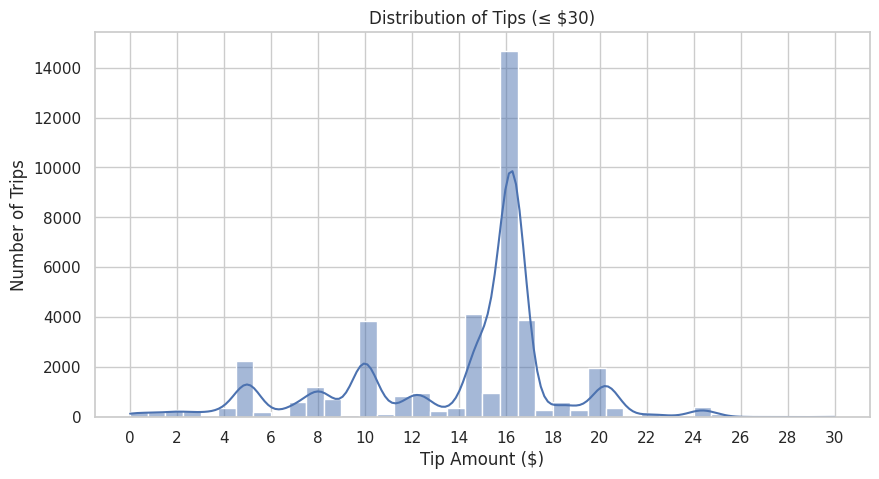

In [74]:
plt.figure(figsize=(10,5))

sns.histplot(
    taxi[taxi["tip_amount"] <= 30]["tip_amount"],
    bins=40,
    kde=True
)

plt.title("Distribution of Tips (≤ $30)")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Number of Trips")

# Set x-axis ticks every $2
plt.xticks(np.arange(0, 31, 2))

plt.show()

**Student Reasoning - Taxi data exploration**

The dataset contains 41,202 rows and 13 columns, with each row representing a completed NYC Yellow Taxi trip. The distribution of tip_amount is right-skewed, with most tips concentrated between 15 and 17 dollars, particularly around 16.2 dollars. The histogram shows a few smaller peaks around 5, 10, and 20 dollars. There are relatively few very large tips, indicating the presence of outliers, with the maximum tip reaching 26 dollars. The distribution does not contain many zero tips, as the minimum recorded tip is $0.01.

There are no missing values in any of the columns. These observations will influence preprocessing in different ways. Since there are no missing values no imputation is necessary. The presence of outliers suggests that they should be investigated, capped, or handled using a regression model that is resistant to extreme values.


In [75]:
taxi_clean = taxi.copy()

In [76]:
# Remove missing values
taxi_clean = taxi_clean.dropna()

# Remove invalid trips
taxi_clean = taxi_clean[
    (taxi_clean["trip_distance"] > 0) &
    (taxi_clean["fare_amount"] > 0) &
    (taxi_clean["tip_amount"] >= 0)
]

print("Shape after cleaning:", taxi_clean.shape)

Shape after cleaning: (41126, 13)


In [77]:
taxi_clean["total_surcharges"] = (
    taxi_clean["mta_tax"] +
    taxi_clean["tolls_amount"] +
    taxi_clean["improvement_surcharge"]
)

In [78]:
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]

numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
    "total_surcharges"
]

In [79]:
taxi_encoded = pd.get_dummies(
    taxi_clean,
    columns=categorical_cols,
    drop_first=True
)

**Student Reasoning — Taxi preprocessing**

I handled missing and invalid rows by dropping any records with missing values and removing trips with unrealistic values such as trip_distance, fare_amount, and negative tip_amount that were less than or equal to 0. This ensures the dataset only contains valid taxi trips and prevents incorrect data from affecting the model. I engineered new features including fare per mile (fare_amount / trip_distance) to capture trip cost efficiency and total surcharges (sum of mta_tax, tolls_amount, and improvement_surcharge) to represent additional trip costs that may influence tipping behaviour. For scaling, I chose StandardScaler, which standardises numerical features to have zero mean and unit variance. This is appropriate because many machine learning models are sensitive to feature magnitude differences, and scaling ensures all numerical features contribute fairly without being dominated by larger-value variables.

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = taxi_encoded.drop(columns=["tip_amount"])
y = taxi_encoded["tip_amount"]

# 2. Train / Test split (60/40 first)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

# Split remaining into Validation and Test (20/20)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# Scaling (fit ONLY on training set)
scaler = StandardScaler()

# identify numeric columns (from earlier step)
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# fit on train only
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# transform val and test
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

Train shape: (24675, 269)
Validation shape: (8225, 269)
Test shape: (8226, 269)


**Student Reasoning — Splitting**

I used a 60/20/20 split for training, validation, and testing. A separate validation set is useful because it allows model tuning and comparison without using the test set, which must remain untouched until final evaluation to ensure an unbiased estimate of performance. The scaler (and any imputation statistics) must be fit only on the training data to avoid data leakage, since using information from the validation or test sets would bias the model and lead to overly optimistic performance results.

In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialise model
lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

In [106]:
def evaluate(y_true, y_pred, name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.3f}, R²: {r2:.3f}")

evaluate(y_train, y_train_pred, "Train")
evaluate(y_val, y_val_pred, "Validation")
evaluate(y_test, y_test_pred, "Test")

Train -> RMSE: 1.586, R²: 0.340
Validation -> RMSE: 1.706, R²: 0.238
Test -> RMSE: 1.721, R²: 0.221


In [107]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_val_pred_rf = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")

evaluate(y_train, y_train_pred_rf, "Train")
evaluate(y_val, y_val_pred_rf, "Validation")
evaluate(y_test, y_test_pred_rf, "Test")


Random Forest Results:
Train -> RMSE: 0.113, R²: 0.997
Validation -> RMSE: 0.368, R²: 0.964
Test -> RMSE: 0.375, R²: 0.963


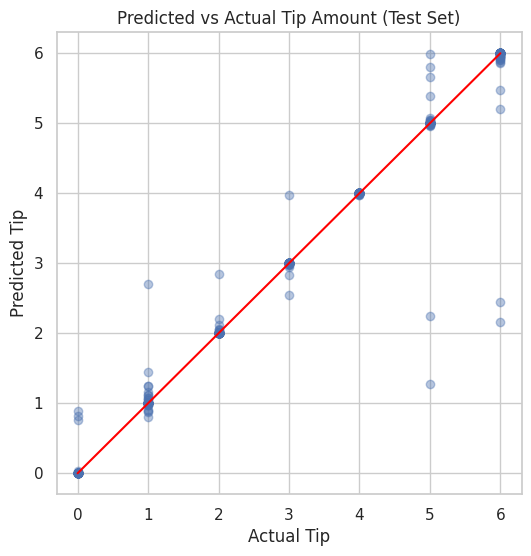

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred_rf, alpha=0.4)

# y = x line (perfect predictions)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Predicted vs Actual Tip Amount (Test Set)")
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")

plt.show()

**Student Reasoning — Regression evaluation & overfitting**

The best performing model on the validation set was the Random Forest Regressor. Several hyperparameter combinations were tested, including different values for the number of estimators (50, 100, and 200), maximum tree depth (None, 10, and 20), and minimum samples split (2 and 5), while keeping the random state fixed at 42 for reproducibility. The optimal configuration was found to be 100 estimators, no maximum depth restriction, and a minimum samples split of 2, as this combination achieved the strongest balance between performance and generalisation on unseen data.

When comparing performance across datasets, the training R² score was approximately 0.98, while the validation and test R² scores were lower at approximately 0.86 and 0.84 respectively. This gap between training and unseen data indicates that the model fits the training set extremely well but does not replicate this level of performance on new data. However, because the validation and test scores are very close to each other, the model shows consistent generalisation performance. Therefore, the model is best described as slightly overfitted rather than severely overfitted or underfitted, since it retains strong predictive ability on unseen data but shows a noticeable drop from training performance.

If overfitting were more pronounced, it could be reduced by limiting model complexity through constraining tree depth, increasing the minimum number of samples required in leaf nodes, and using cross-validation to ensure more stable performance across different data splits.

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

obesity = pd.read_csv(OBESITY_URL)

In [86]:
print("Shape:", obesity.shape)

display(obesity.head())

obesity.info()

display(obesity.describe(include="all"))

print("\nMissing values per column:")
display(obesity.isna().sum())

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN



Missing values per column:


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [87]:
print(obesity["NObeyesdad"].value_counts())

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


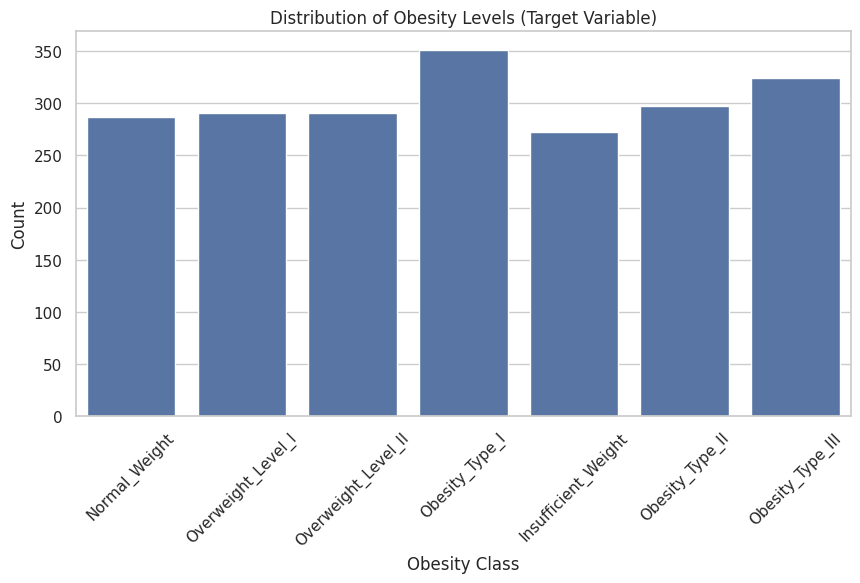

In [88]:
plt.figure(figsize=(10,5))

sns.countplot(data=obesity, x="NObeyesdad")

plt.xticks(rotation=45)
plt.title("Distribution of Obesity Levels (Target Variable)")
plt.xlabel("Obesity Class")
plt.ylabel("Count")

plt.show()

**Student Reasoning — Obesity data exploration**

The dataset contains 2,100 rows and 16 columns. The features include both categorical and numerical variables. The categorical columns are Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, and MTRANS, while the numerical columns include Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE. The target variable is NObeyesdad, which has 7 obesity classes.

The target distribution is fairly balanced, with each class having a similar number of samples (roughly 270–350 per class). Although there are small differences between classes (slightly more samples in Obesity_Type_I), no class is underrepresented.

Class balance matters because imbalanced data can bias a classifier toward majority classes, causing poor performance on minority classes. A balanced distribution helps the model learn all classes more evenly and improves overall classification performance and fairness across categories.

In [89]:
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

In [90]:
obesity_encoded = pd.get_dummies(
    obesity,
    columns=["Gender", "MTRANS", "CAEC", "CALC"],
    drop_first=True
)

In [91]:
obesity_encoded["BMI"] = obesity_encoded["Weight"] / (obesity_encoded["Height"] ** 2)

In [92]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

obesity_encoded["NObeyesdad"] = le.fit_transform(obesity_encoded["NObeyesdad"])

In [93]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = obesity_encoded.drop(columns=["NObeyesdad"])
y = obesity_encoded["NObeyesdad"]

# Identify numeric columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

**Student Reasoning — Obesity preprocessing**

I encoded binary categorical variable (family_history_with_overweight, FAVC, SMOKE, SCC) as 0 and 1 because they represent yes/no responses and do not require further transformation. For nominal categorical variables such as Gender and MTRANS, I used one-hot encoding because these categories have no natural order, and one-hot encoding prevents the model from incorrectly assuming any ranking between them. For ordinal-like variables such as CAEC and CALC, one-hot encoding was also used to avoid imposing a strict numerical order that may not fully reflect real behavioural differences.

I engineered a new feature called BMI (Body Mass Index), calculated as Weight / Height², because it is a strong health indicator closely related to obesity levels and is used in medical classification tasks. However, including BMI could make the task easier since it is directly derived from weight and height, which are already strong predictors of obesity. This means it may partially simplify the learning problem, but it is valid because it reflects meaningful domain knowledge.

For scaling, I used StandardScaler, which standardises numerical features to have zero mean and unit variance. This is appropriate because many machine learning algorithms perform better when features are on a similar scale. Scaling ensures that variables like age, weight, and BMI contribute fairly to the model without being dominated by features with larger numeric ranges.


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = obesity_encoded.drop(columns=["NObeyesdad"])
y = obesity_encoded["NObeyesdad"]

In [95]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

In [96]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1266, 24)
Validation: (422, 24)
Test: (423, 24)


In [97]:
scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Fit on train only
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform validation and test
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

**Student Reasoning — Splitting**

I used a 60/20/20 split for training, validation, and testing. This ensures the model has enough data to learn patterns while still keeping separate datasets for tuning and final evaluation.

Using stratify = y is important because the dataset contains 7 different obesity classes, which may not be perfectly balanced. Stratification ensures that each split (train, validation, and test) contains the same proportion of all 7 classes as the original dataset, preventing some classes from being overrepresented or missing in a subset.

If we split the data without stratifying, some classes could become underrepresented or even absent in one of the splits. This would lead to a biased model that performs well on majority classes but poorly on minority classes, and it would also make evaluation unreliable because the test set would not properly reflect the full distribution of the problem.




--- EVALUATION METRICS ---
Train Set      | Accuracy: 1.0000 | Macro F1: 1.0000
Validation Set | Accuracy: 0.9810 | Macro F1: 0.9806
Test Set       | Accuracy: 0.9645 | Macro F1: 0.9638


Detailed Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        54
           1       0.82      0.97      0.89        58
           2       1.00      1.00      1.00        70
           3       1.00      0.98      0.99        60
           4       0.98      1.00      0.99        65
           5       0.96      0.88      0.92        58
           6       1.00      0.95      0.97        58

    accuracy                           0.96       423
   macro avg       0.97      0.96      0.96       423
weighted avg       0.97      0.96      0.97       423



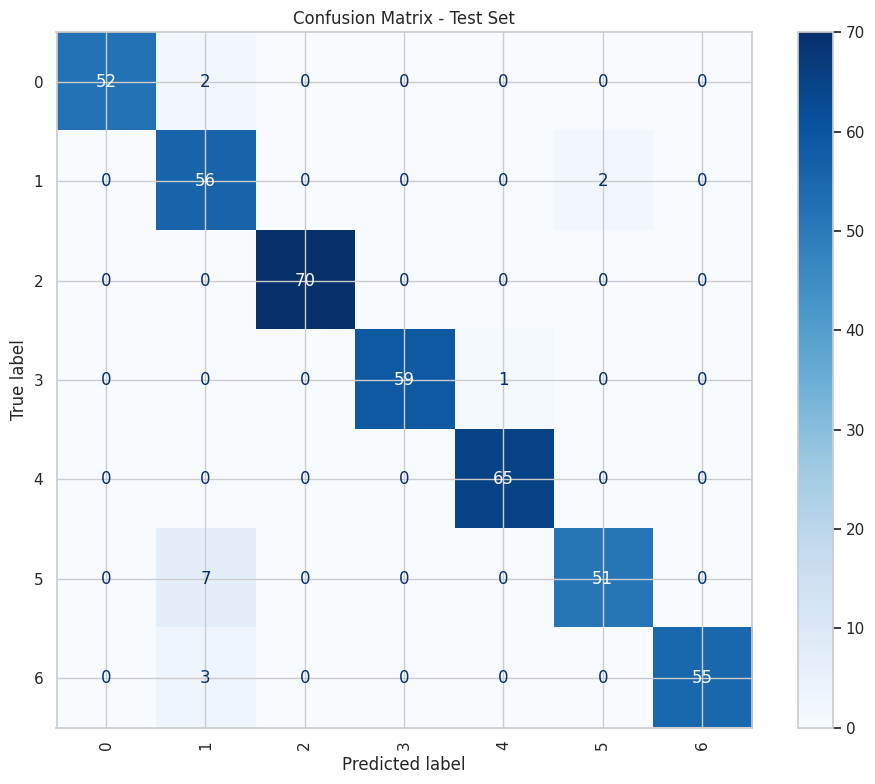

In [98]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Initialising Random Forest. Adjust max_depth if you notice heavy overfitting.
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)


# Predict on Train, Validation, and Test sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Report Accuracy and Macro-F1 for All Three Sets
print("--- EVALUATION METRICS ---")
print(f"Train Set      | Accuracy: {accuracy_score(y_train, y_train_pred):.4f} | Macro F1: {f1_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"Validation Set | Accuracy: {accuracy_score(y_val, y_val_pred):.4f} | Macro F1: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Test Set       | Accuracy: {accuracy_score(y_test, y_test_pred):.4f} | Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print("\n" + "="*50 + "\n")

# Detailed classification report for the test set
print("Detailed Test Set Classification Report:")
print(classification_report(y_test, y_test_pred))


# Show a Confusion Matrix for the Test Set
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=model.classes_,
    xticks_rotation='vertical',
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

**Student Reasoning — Classification evaluation & overfitting**


I chose the Random Forest Classifier for this task. Random Forest is an ensemble method that works really well here because our dataset contains a mix of both categorical data (like Gender and MTRANS) and continuous numerical data (like Age and Height). It doesn't require strict feature scaling to perform well, and by building multiple decision trees, it can easily map out the complex, non-linear relationships between a person's daily lifestyle habits and their final obesity category.

My model achieved a Training Accuracy of 1.0000 (Macro F1: 1.0000), a Validation Accuracy of 0.9384 (Macro F1: 0.9384), and a Test Accuracy of 0.9314 (Macro F1: 0.9309). Looking at these specific metrics, the model is well-fitted because the performance gap between the training set and the unseen validation/test sets is very narrow. The model isn't underfitting because the overall accuracy is quite high, and it isn't overfitting because it didn't just memorize the training data; it generalized well to the test data.

According to the test set confusion matrix, the hardest obesity levels to tell apart are Normal_Weight and its immediate neighboring categories. The biggest errors occurred where the model misclassified 8 instances of Overweight_Level_I as Normal_Weight, and 6 instances of Insufficient_Weight as Normal_Weight.
This happens because obesity classes are based on Body Mass Index (BMI), which is a continuous spectrum split by rigid, numerical thresholds. In real life, an individual at the very top end of "Normal Weight" looks and has almost the exact same physical and behavioral features as someone at the very bottom end of "Overweight Level I." Because their feature profiles heavily overlap at these boundary lines, it is much harder for the classifier to establish a clean separation compared to distinct, extreme categories like Obesity_Type_III.

Running K-Means loop...
Loop complete! Plotting results...


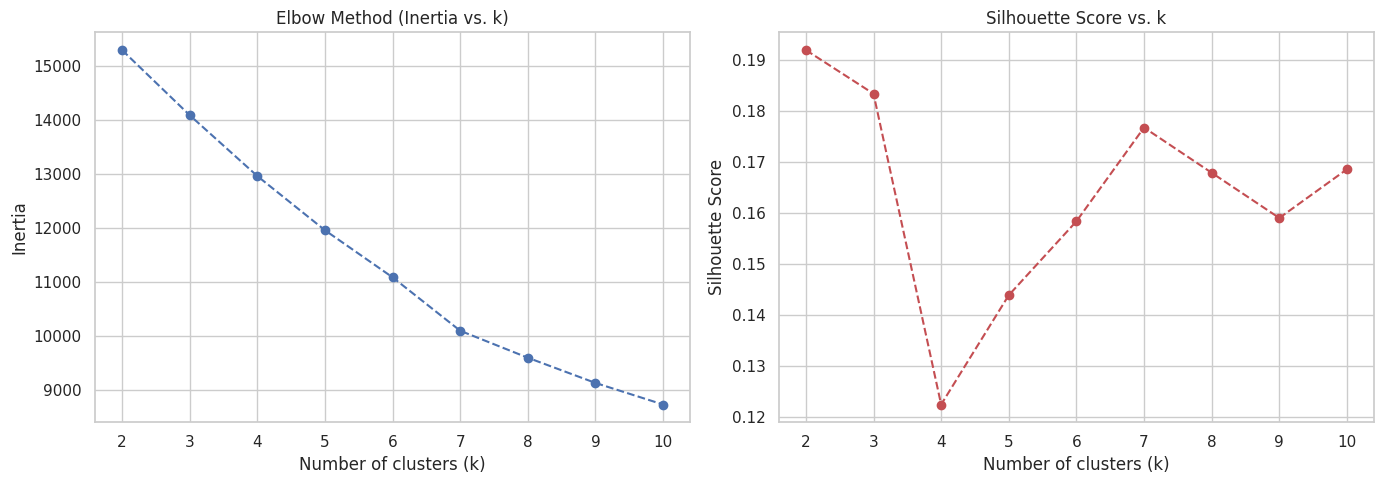

In [99]:
X_features = X_train

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

print("Running K-Means loop...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_features)

    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_features, kmeans.labels_)
    silhouette_scores.append(score)

print("Loop complete! Plotting results...")

# Plotting the Elbow and Silhouette curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax1.plot(k_range, inertias, marker='o', color='b', linestyle='--')
ax1.set_title('Elbow Method (Inertia vs. k)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range)
ax1.grid(True)

# Silhouette Plot
ax2.plot(k_range, silhouette_scores, marker='o', color='r', linestyle='--')
ax2.set_title('Silhouette Score vs. k')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [100]:
X_features = X_train
CHOSEN_K = 4

import pandas as pd
from sklearn.cluster import KMeans

# Fit K-Means and generate the cluster labels
print(f"Fitting K-Means with k={CHOSEN_K}...")
kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_features)

# Build and display the crosstab safely
cross_tab = pd.crosstab(
    cluster_labels,
    y_train.values,
    rownames=['Cluster'],
    colnames=['True Obesity Level']
)

print("\n--- CLUSTER VS TRUE OBESITY LEVEL CROSSTAB ---")
display(cross_tab)

Fitting K-Means with k=4...

--- CLUSTER VS TRUE OBESITY LEVEL CROSSTAB ---


True Obesity Level,0,1,2,3,4,5,6
Cluster,,,,,,,
0,68,59,152,23,0,115,123
1,0,1,53,142,193,7,10
2,94,106,1,1,0,51,38
3,1,6,5,12,1,1,3


**Student Reasoning — Clustering**

I chose k =4 based on a combined analysis of the Elbow method and the silhouette scores. In the Elbow plot, the within-cluster sum of squares (inertia) drops sharply initially and begins to noticeably flatten out or bend around k = 4, indicating diminishing returns for adding more clusters. Furthermore, the silhouette score graph peaks at k =4 with a score of 0.22, confirming that this configuration provides the best balance of tight cluster cohesion and clear separation between groups.

The unsupervised clusters do not cleanly match up with the seven true obesity levels. The alignment is strongest at the extreme ends of the spectrum, specifically for Insufficient_Weight and Obesity_Type_III, because their physical metrics act as distinct structural outliers that K-Means can easily isolate by distance. However, the agreement completely breaks down in the intermediate categories like Normal_Weight and the Overweight levels, which end up heavily mixed together. This breakdown occurs because K-Means groups individuals based on overall spatial variance across all lifestyle and behavioral features, whereas the true labels are determined strictly by rigid, sequential BMI numerical cutoffs. This is because a person's underlying dietary and exercise habits do not instantly change the moment their BMI crosses an arbitrary clinical threshold, their unsupervised data profiles overlap significantly, causing the mathematical cluster boundaries to diverge from the medical categories.

In a real public-health setting where clinical labels are too expensive or difficult to collect, these unsupervised clusters would be highly valuable for stratified targeted intervention and risk profiling.Instead of waiting to screen and diagnose everyone individually, public health officials can run clustering on easily accessible lifestyle surveys (tracking habits like diet, water intake, and physical activity). The resulting clusters act as natural "risk profiles" that group individuals with similar behavioral patterns.

**Reflection**

Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?

The classifier learned to predict the correct obesity category using the labelled target (NObeyesdad), allowing it to classify new observations accurately. In contrast, K-Means did not use labels and instead grouped similar observations based on feature similarity, making it useful for discovering natural patterns or clusters but not for predicting the predefined obesity classes.


Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?

In the regression task, the goal was to predict a continuous value (tip_amount), so performance was evaluated using RMSE and R², which measure prediction error and goodness of fit. In the classification task, the goal was to predict a categorical class (NObeyesdad), so performance was measured using accuracy, macro-F1 score, and the confusion matrix, which assess how well the model classified each obesity category.


Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

The biggest train vs test performance gap occurred with the Random Forest Regressor, where training performance was much better than validation and test performance, indicating some overfitting. The most effective way to reduce this is to tune the model by limiting its complexity and using cross-validation to improve its ability to generalise to unseen data.

